# I-ROCKET Explanation Evaluation: TSHAP + AMEE

## Waveform dataset

This notebook compares I-ROCKET's built-in interpretability tools with
TSHAP (Le Nguyen and Ifrim, 2025) using the AMEE evaluation framework
(Nguyen et al., 2024).

**I-ROCKET** provides model-level saliency maps derived analytically
from the known kernel structure: temporal importance profiles identify
where features differ across classes, and occlusion sensitivity
measures where perturbation changes predictions.

**TSHAP** provides instance-level Shapley value attributions by
grouping timepoints into sliding windows. It is model-agnostic and
computes exact (not approximate) SHAP values.

**AMEE** evaluates both by perturbing the most important timepoints
and measuring accuracy drop. This tells us which saliency map best
identifies the regions the classifier depends on.

References:
  Le Nguyen, T. and Ifrim, G. (2025). TSHAP: Fast and Exact SHAP
      for Explaining Time Series Classification and Regression.
      ECML-PKDD 2025.
  Nguyen, T.T., Nguyen, T.L., and Ifrim, G. (2024). Robust explainer
      recommendation for time series classification. DMKD, 38:3372-3413.

In [1]:
# Suppress OpenMP diagnostic messages that numba triggers on startup.
# These are informational only and do not affect results.
import os
os.environ["OMP_DISPLAY_ENV"] = "FALSE"
os.environ["KMP_WARNINGS"] = "0"

import numpy as np
import matplotlib.pyplot as plt
import time

import interp_rocket as IR

RANDOM_STATE = 42

#### NOTE

This notebook depends on the tshap package: https://github.com/mlgig/tshap

## 1. Setup: data, model, and feature selection

In [2]:
from sklearn.datasets import fetch_openml

waveform = fetch_openml(name='waveform-5000', version=1, as_frame=False)
X = waveform.data[:, :21].astype(np.float32)
y = waveform.target.astype(int)

InterpRocket.fit: 5000 instances × 21 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 1176 biases across 2 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 1176 biases across 2 dilations...
  Transforming training data...
  Feature matrix: (5000, 9408)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 0.9764
  Selected alpha: 4832.9302
CV feature stability: 5x5 folds, tracking top 50 features per fold
  Round 1/5: 103 features appeared in every round so far
  Round 2/5: 84 features appeared in every round so far
  Round 3/5: 73 features appeared in every round so far
  Round 4/5: 68 features appeared in every round so far
  Round 5/5: 68 features appeared in every round so far

  Features in ALL folds:  15
  Features in ≥80% folds: 25
  Features in NO folds:   4514
Stable features (≥80% of 25 folds): 25


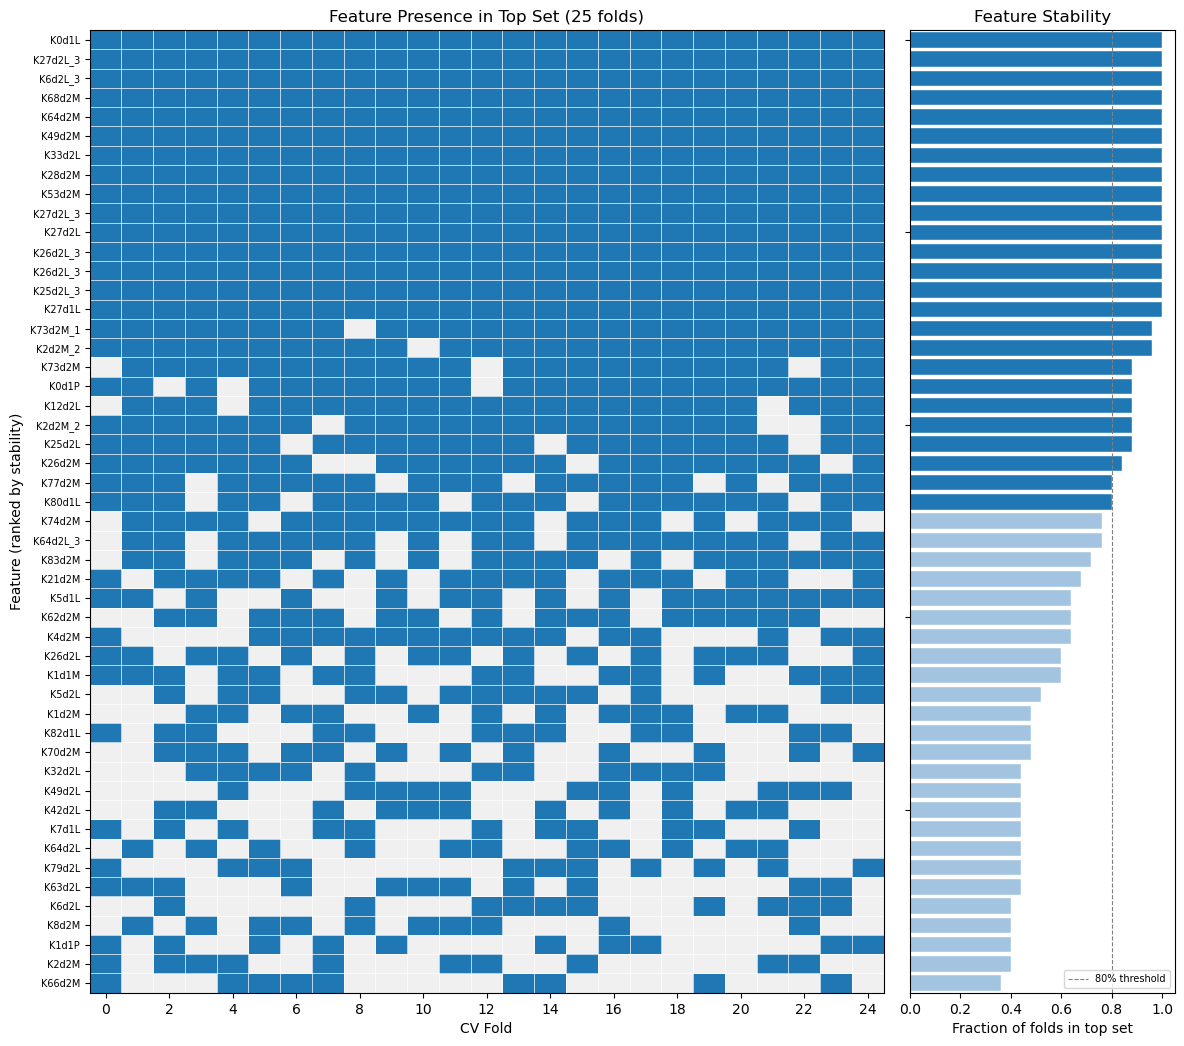

In [3]:
# Fit a reference model on all data for stability analysis
model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000
)
model.fit(X, y)

# Feature stability analysis
stability = IR.cv_feature_stability(X, y, n_repeats=5, n_folds=5, n_top=50)
fig = IR.plot_feature_stability(stability, model=model)

stable_features = IR.get_stable_features(stability, threshold=0.8)

In [4]:
# Decode stable features and filter by dilation
low_dil_features = []
for fi in stable_features:
    info = model.decode_feature_index(int(fi))
    if info['dilation'] <= 2:  # RF <= 17 timepoints
        low_dil_features.append(fi)

low_dil_features = np.array(low_dil_features)
print(f"Stable features: {len(stable_features)}")
print(f"Low-dilation (d<=2): {len(low_dil_features)}")

Stable features: 25
Low-dilation (d<=2): 25


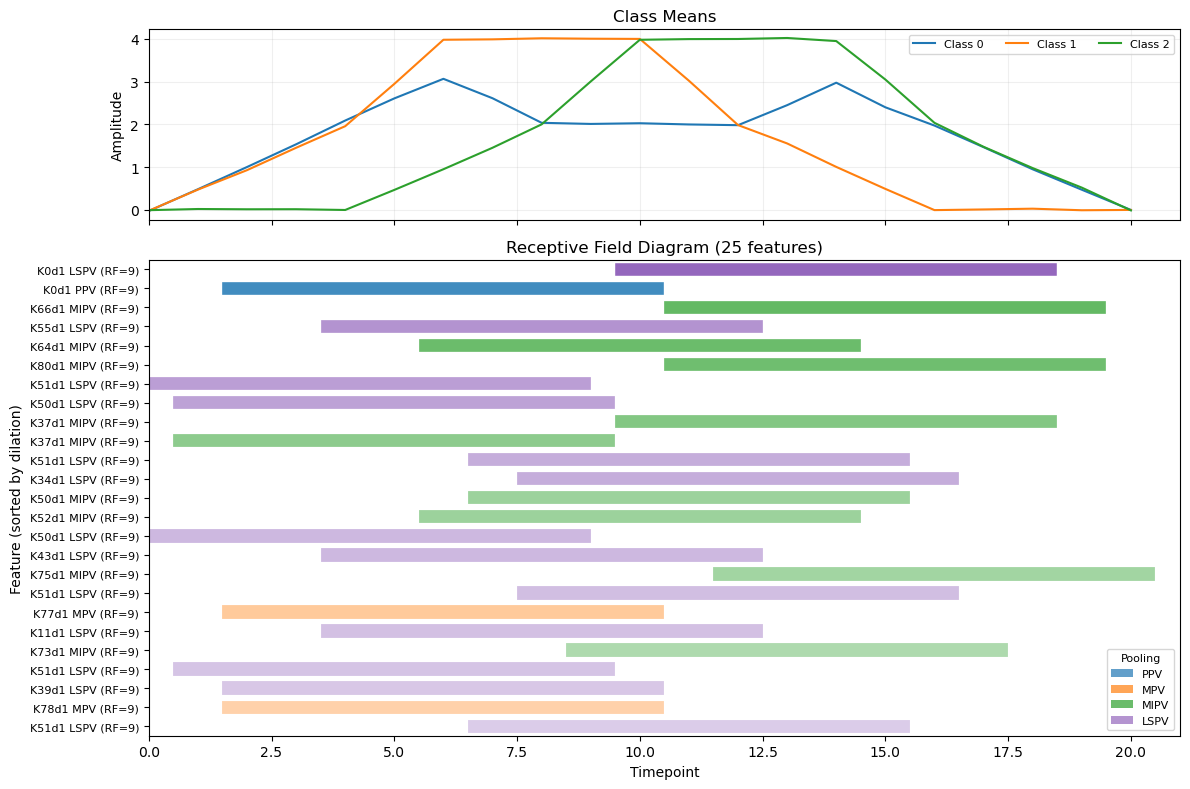

In [5]:
fig = IR.plot_receptive_field_diagram(
    model, X, y, feature_mask=stable_features
)

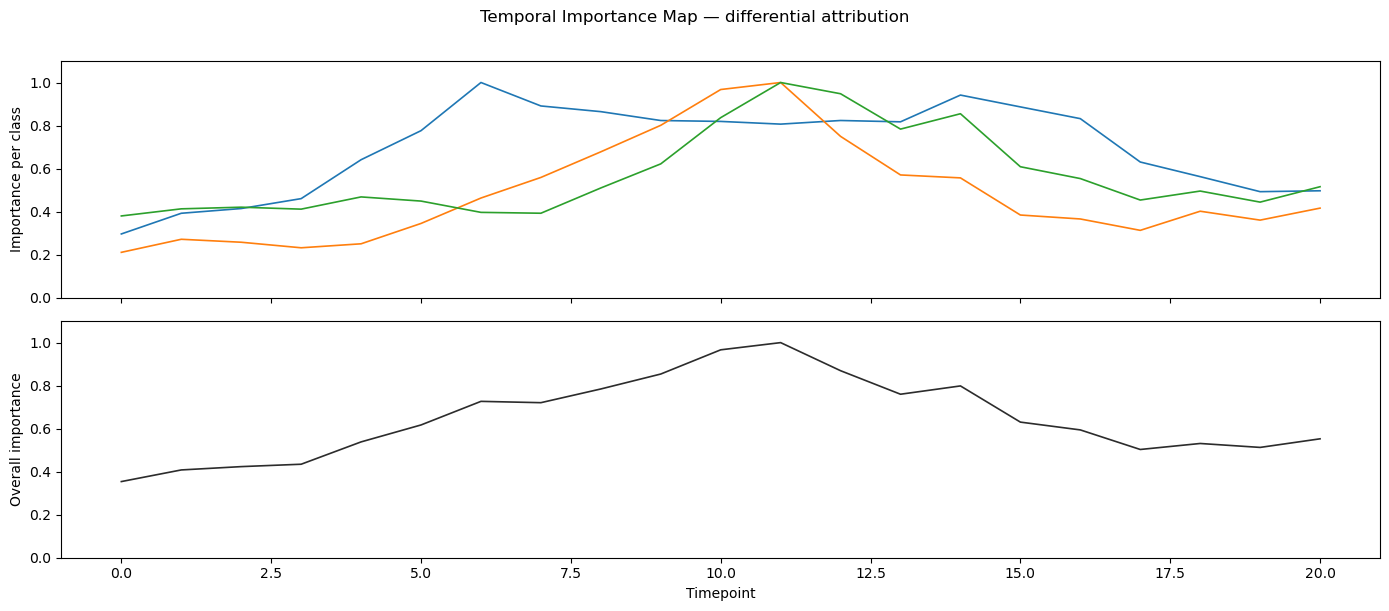

In [6]:
fig, imp_all = model.plot_temporal_importance(
    X, y, feature_mask=stable_features
)

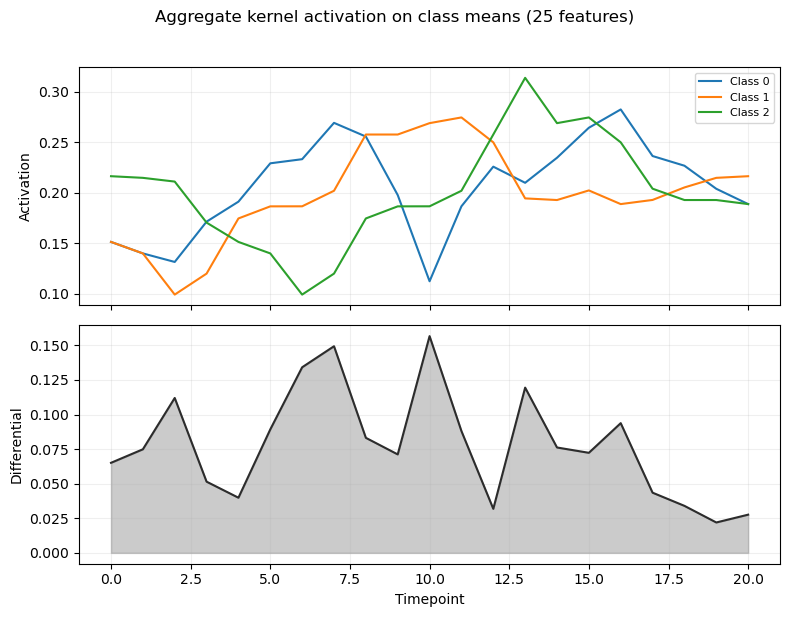

In [7]:
fig, class_act, diff = IR.plot_aggregate_activation(model, X, y,feature_mask=stable_features)

# Normalize diff output from plot_aggregate_activation to [0, 1] for AMEE
s_aggregate = np.abs(diff)
if s_aggregate.max() > 0:
    s_aggregate /= s_aggregate.max()

# COMMENT:
# The differential method in plot_temporal_importance counts how often 
# a kernel fires (binary: above or below bias), while plot_aggregate_activation 
# measures how strongly the kernel responds (continuous: the actual convolution 
# magnitude weighted by importance). On data with graded signal differences 
# across classes, the continuous version should localize better.

## 2. Extract saliency maps from all methods

We extract six saliency maps:

1. I-ROCKET temporal importance - binary activation profile comparing how often kernels fire above threshold across classes
2. I-ROCKET aggregate diff - continuous convolution magnitude on class means, weighted by feature importance
3. I-ROCKET occlusion - sliding-window perturbation measuring accuracy drop when each temporal region is masked
4. TSHAP Window - Shapley attributions computed over sliding windows
5. TSHAP ROI - Shapley attributions aggregated into contiguous regions of interest
6. Random - uniform baseline

The distinction between #1 and #2 matters: Temporal importance counts whether a kernel fires (binary, above/below bias). Aggregate diff measures how strongly the kernel responds (continuous convolution output). 

For TSHAP, we use a subset of samples for computational efficiency.

In [8]:
from amee_evaluation import (
    extract_temporal_importance,
    extract_occlusion_saliency,
    random_saliency,
    inverse_saliency,
)
from tshap_integration import extract_tshap_saliency

# --- I-ROCKET methods ---
t0 = time.time()
s_temporal = extract_temporal_importance(
    model, X, y, feature_mask=stable_features
)
t_temporal = time.time() - t0
print(f"Temporal importance: {t_temporal:.1f}s")

t0 = time.time()
s_occlusion = extract_occlusion_saliency(
    model, X, y, feature_mask=stable_features
)
t_occlusion = time.time() - t0
print(f"Occlusion: {t_occlusion:.1f}s")

# --- TSHAP ---
# window length and stride are brief given the signals only have 21 timepoints
t0 = time.time()
tshap_results = extract_tshap_saliency(
    model, X,
    window_length=5, stride=2,
    n_background=20,
    random_state=RANDOM_STATE,
)
t_tshap = time.time() - t0
print(f"TSHAP: {t_tshap:.1f}s")

# --- Baselines ---
s_random = random_saliency(X.shape[1], random_state=RANDOM_STATE)

Temporal importance: 0.0s
Occlusion: 0.8s
TSHAP: 5000 samples, window=5, stride=2, 20 background samples
  Window attr range: [-0.2530, 0.2684]
  ROI attr range: [-0.1785, 0.1431]
TSHAP: 138.3s


## 3. Visualize: I-ROCKET vs TSHAP saliency maps

Compare the three approaches overlaid on class means.
I-ROCKET's temporal importance is model-level (one map for the
dataset). TSHAP attributions are instance-level, averaged here
to produce a dataset-level summary.

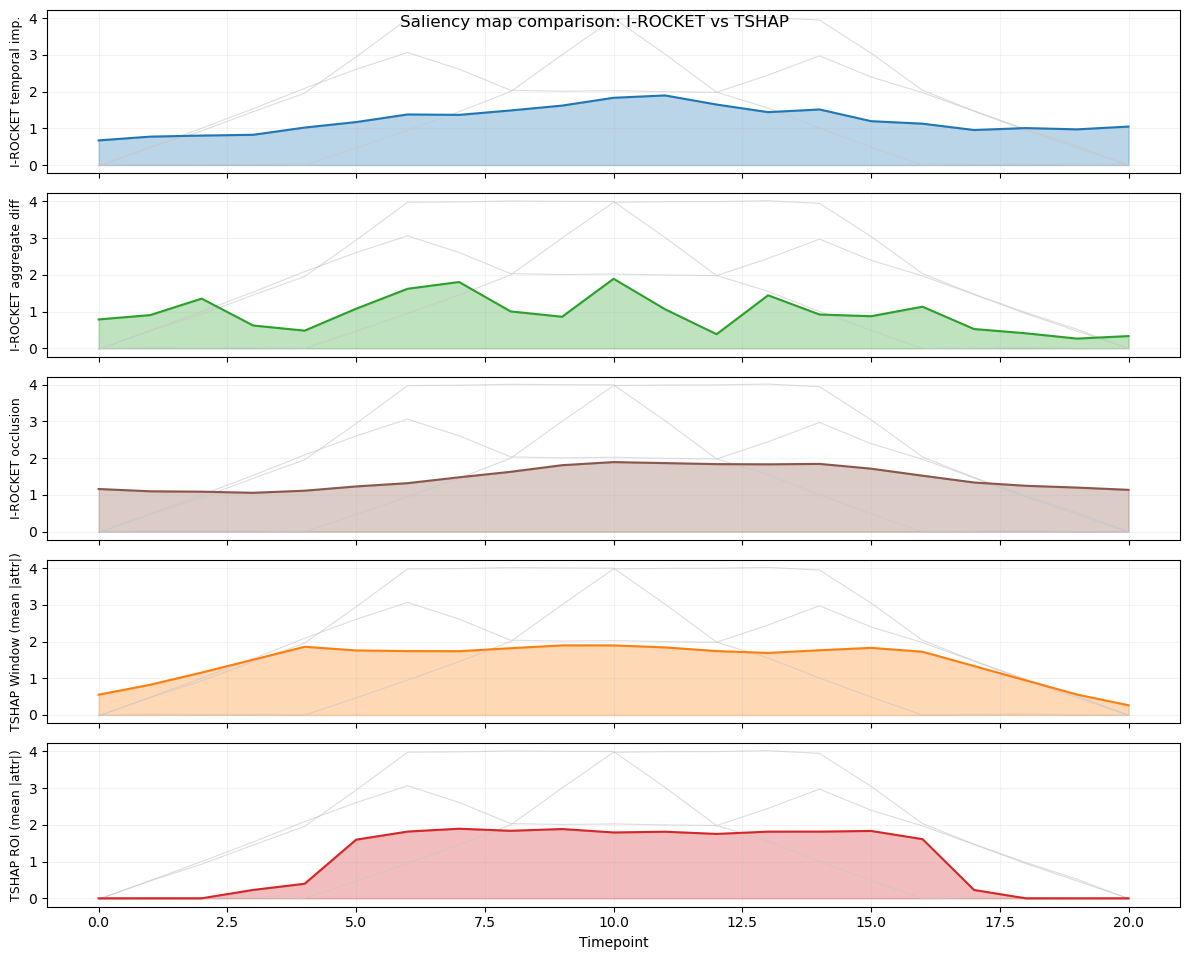

In [9]:
from tshap_integration import plot_tshap_vs_irocket

fig = plot_tshap_vs_irocket(
    X, y, tshap_results, s_temporal,
    aggregate_diff=s_aggregate,
    occlusion_saliency=s_occlusion,
)

## 4. TSHAP instance-level attributions

Unlike I-ROCKET's model-level profiles, TSHAP produces a saliency
map per instance. Red regions contribute positively to the
prediction, blue regions negatively.

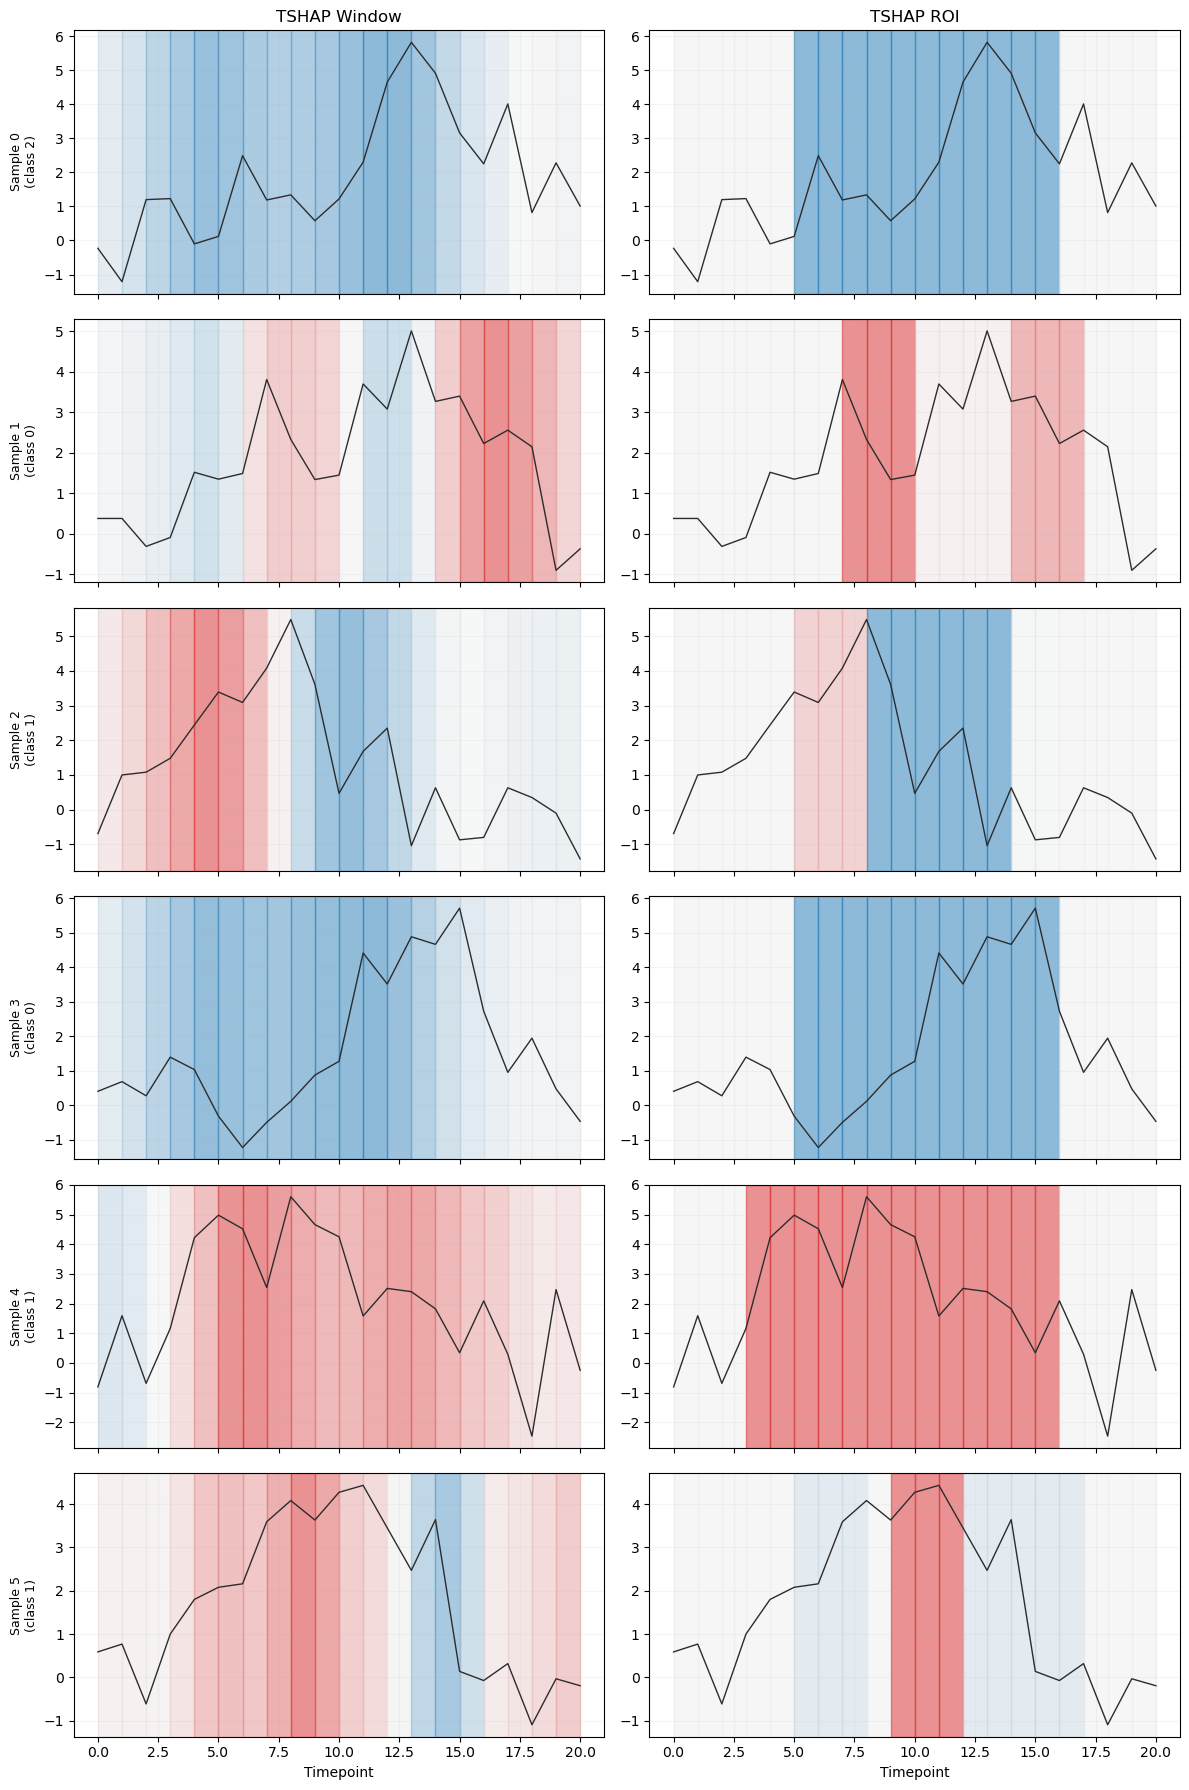

In [10]:
from tshap_integration import plot_tshap_attributions

fig = plot_tshap_attributions(X, y, tshap_results, n_show=6)

## 5. AMEE evaluation: which explainer is most informative?

We feed all five saliency maps into AMEE. For TSHAP, we use the
mean absolute attribution across instances as the dataset-level
saliency map, making it comparable with I-ROCKET's model-level
profiles.

In [11]:
from amee_evaluation import amee_evaluate, plot_amee_results

saliency_maps = {    
    "TSHAP Window": tshap_results['mean_window'],
    "TSHAP ROI": tshap_results['mean_roi'],
    "IR temporal imp.": s_temporal,
    "IR aggregate diff": s_aggregate,
    "IR occlusion": s_occlusion,
    "Random": s_random,
}

amee_results = amee_evaluate(
    model, X, y, saliency_maps,
    random_state=RANDOM_STATE,
)

               TSHAP Window + zero    : AUC drop = 0.2474
               TSHAP Window + mean    : AUC drop = 0.1975
               TSHAP Window + noise   : AUC drop = 0.1859
               TSHAP Window + inverse : AUC drop = 0.2117
                  TSHAP ROI + zero    : AUC drop = 0.1896
                  TSHAP ROI + mean    : AUC drop = 0.1487
                  TSHAP ROI + noise   : AUC drop = 0.1504
                  TSHAP ROI + inverse : AUC drop = 0.1668
           IR temporal imp. + zero    : AUC drop = 0.2584
           IR temporal imp. + mean    : AUC drop = 0.2008
           IR temporal imp. + noise   : AUC drop = 0.1885
           IR temporal imp. + inverse : AUC drop = 0.2245
          IR aggregate diff + zero    : AUC drop = 0.1840
          IR aggregate diff + mean    : AUC drop = 0.1421
          IR aggregate diff + noise   : AUC drop = 0.1462
          IR aggregate diff + inverse : AUC drop = 0.1536
               IR occlusion + zero    : AUC drop = 0.2380
              

## 6. AMEE ranking

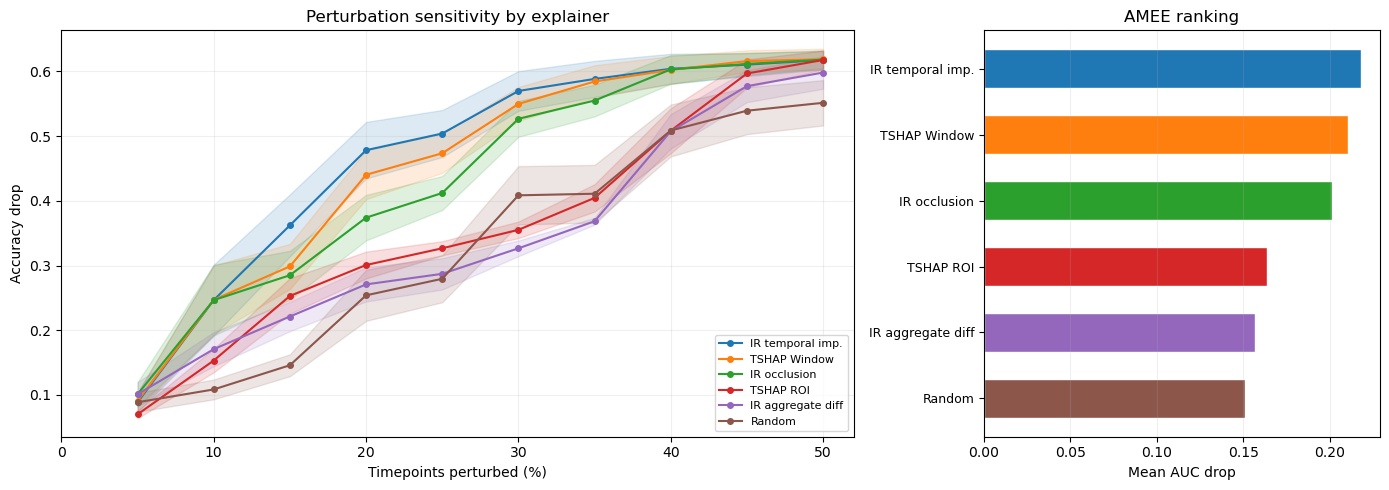

In [12]:
fig = plot_amee_results(amee_results)

## 7. Summary across perturbations

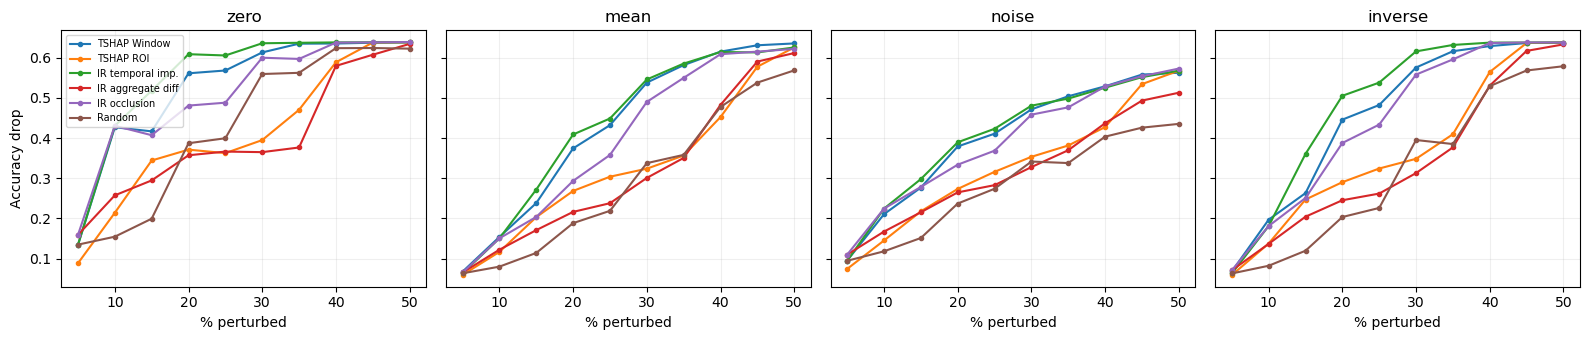

In [13]:
TAB10 = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
]

perturbations = ["zero", "mean", "noise", "inverse"]
explainer_names = list(saliency_maps.keys())

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, pert in zip(axes, perturbations):
    for i, name in enumerate(explainer_names):
        res = amee_results["per_explainer"][name][pert]
        ax.plot(
            res["fractions"] * 100,
            res["accuracy_drops"],
            color=TAB10[i],
            linewidth=1.5,
            marker="o",
            markersize=3,
            label=name if pert == "zero" else None,
        )
    ax.set_title(f"{pert}")
    ax.set_xlabel("% perturbed")
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel("Accuracy drop")
axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout()

## 8. Summary table

In [14]:
print(f"\n{'Explainer':<25s} {'Mean AUC drop':>15s} {'Rank':>6s}")
print("-" * 48)
for rank, (name, auc) in enumerate(amee_results['ranking'], 1):
    print(f"{name:<25s} {auc:>15.4f} {rank:>6d}")


Explainer                   Mean AUC drop   Rank
------------------------------------------------
IR temporal imp.                   0.2181      1
TSHAP Window                       0.2106      2
IR occlusion                       0.2012      3
TSHAP ROI                          0.1639      4
IR aggregate diff                  0.1565      5
Random                             0.1510      6


## 10. Interpretations and Advice on Use

**What I-ROCKET provides that TSHAP does not:**
I-ROCKET's interpretability is *structural*. It tells you not just
*where* the classifier looks, but *what* it detects: which kernel
(a specific pattern of +2/-1 weights), at which dilation (temporal
scale), with which pooling operator (frequency, strength, position,
or persistence of the pattern). The RF diagram shows the receptive
field of each feature overlaid on the temporal importance profile.
This level of mechanistic detail is not available from any
model-agnostic method.

**What TSHAP provides that I-ROCKET does not:**
TSHAP produces *instance-level* attributions with formal game-theoretic
guarantees (additivity, symmetry, null player). This means you can
explain *why a specific sample was classified as class A*, not just
which regions matter in general. 

**Practical Use:** These measures allow for understanding why specific 
trials were misclassified. See the example below for guidance.

In [15]:
# Fit model with random split of the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

model = IR.InterpRocket(
    max_dilations_per_kernel=16,
    num_features=10000
)
model.fit(X_train, y_train)

metrics = model.evaluate(X_test, y_test)
print(f"Accuracy:          {metrics['accuracy']:.4f}")
print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
print(f"F1 (macro):        {metrics['f1_macro']:.4f}")
print(f"MCC:               {metrics['mcc']:.4f}")
print(f"Mutual info:       {metrics['mutual_info']:.4f}")

Train: (3500, 21), Test: (1500, 21)
InterpRocket.fit: 3500 instances × 21 timepoints
  Classes: [0 1 2]
  Fitting dilations (raw)...
  Fitting biases (raw): 1176 biases across 2 dilations...
  Fitting dilations (diff)...
  Fitting biases (diff): 1176 biases across 2 dilations...
  Transforming training data...
  Feature matrix: (3500, 9408)
  Standardizing features...
  Fitting RidgeClassifierCV...
  Training accuracy: 0.9817
  Selected alpha: 4832.9302
Accuracy:          0.8560
Balanced accuracy: 0.8562
F1 (macro):        0.8560
MCC:               0.7841
Mutual info:       0.8484


In [16]:
# Find misclassified trials
y_pred = model.predict(X_test)
corrects = np.where(y_pred == y_test)[0]
errors = np.where(y_pred != y_test)[0]
trials = [corrects[0], errors[0]]
print(trials)

[np.int64(0), np.int64(5)]


Temporal occlusion: window=3, stride=1
  Analyzing 2 samples...
  Sample 0: true=2, pred=2, max_sensitivity=3.4844
  Sample 5: true=0, pred=1, max_sensitivity=2.2042


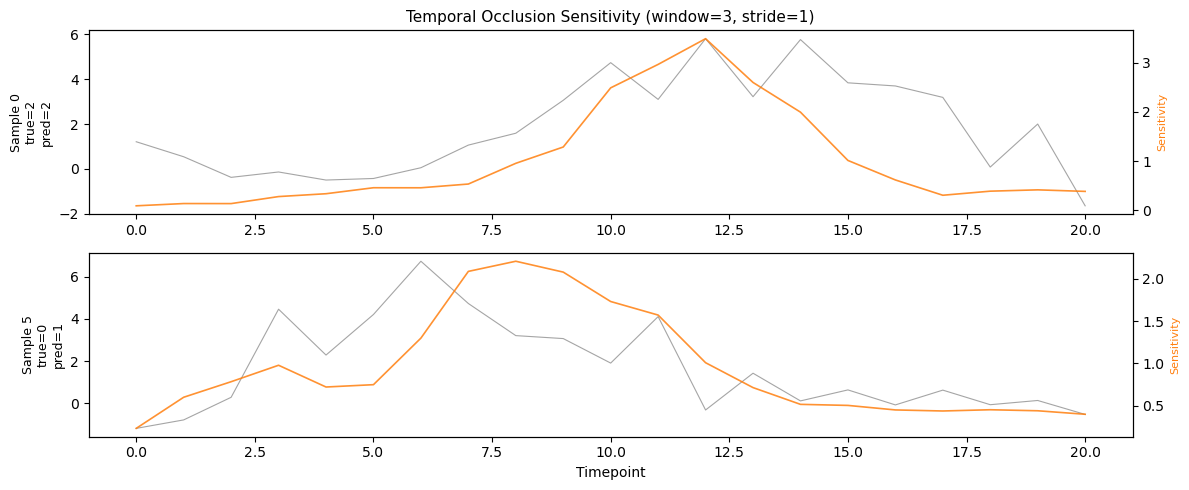

In [17]:
# IR-based temporal occlusion
occ = IR.temporal_occlusion(model, X_test, y_test, sample_indices=trials)
fig = IR.plot_occlusion(occ)

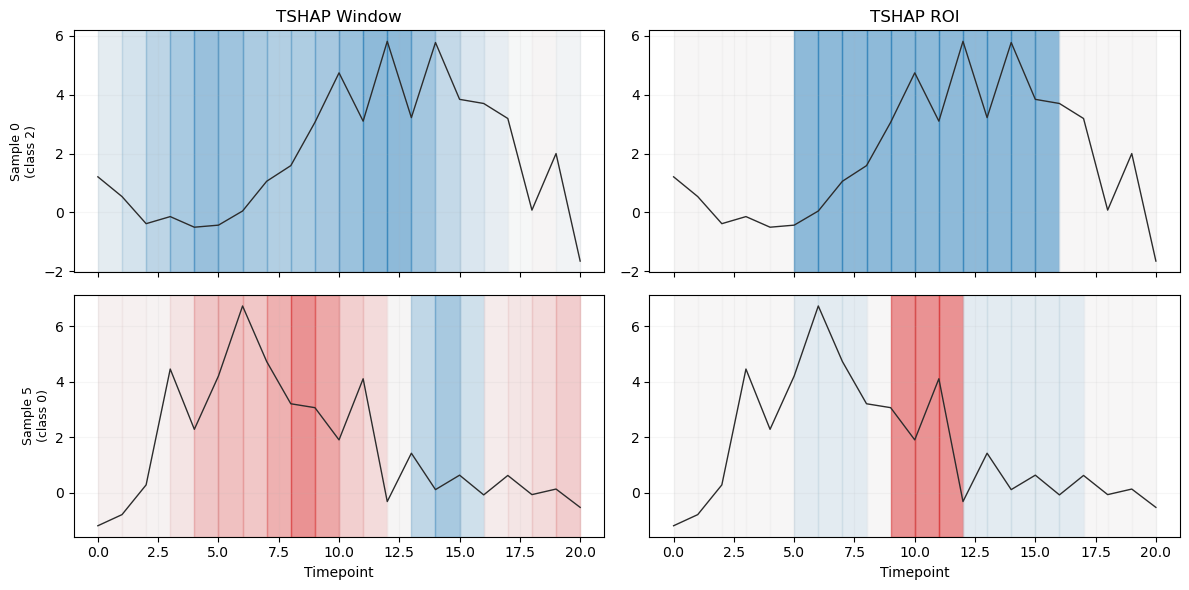

In [18]:
# TSHAP
fig = plot_tshap_attributions(X_test, y_test, tshap_results, sample_indices=trials)